Volume 2 Compton gammas: 1262
Volume 3 Compton gammas: 362


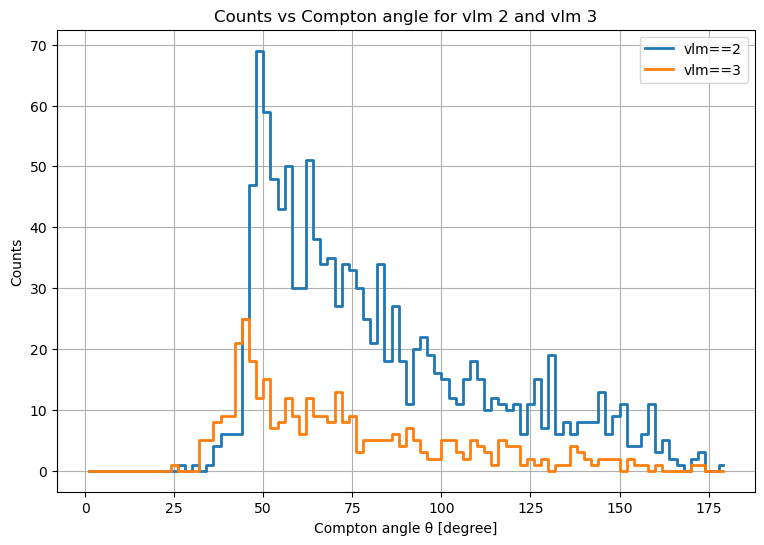

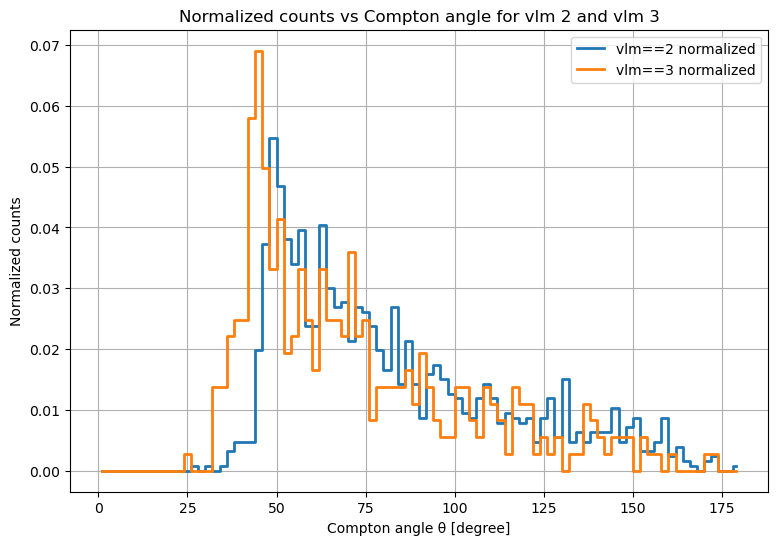

In [5]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
root_file = "sucrose.root"
tree_name = "t"

vlm2 = 2
vlm3 = 3

pdg_code = 22          # gamma
compton_code = 2013

E0 = 662.0             # incident gamma energy [keV]
me = 511.0             # electron rest energy [keV]

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)
if not t:
    raise RuntimeError("Could not find tree")

# =========================
# COLLECT ANGLES
# =========================
theta_vlm2 = []
theta_vlm3 = []

for entry in t:

    n = min(len(entry.pdg), len(entry.vlm), len(entry.pro), len(entry.et))

    for i in range(n):

        # gamma only
        if int(entry.pdg[i]) != pdg_code:
            continue

        # Compton only
        if int(entry.pro[i]) != compton_code:
            continue

        # only volume 2 or 3
        vlm = int(entry.vlm[i])
        if vlm not in [vlm2, vlm3]:
            continue

        Es = float(entry.et[i])   # scattered gamma energy [keV]

        if Es <= 0 or Es >= E0:
            continue

        # Compton angle from energy
        cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

        if cos_theta < -1.0 or cos_theta > 1.0:
            continue

        theta_deg = math.degrees(math.acos(cos_theta))

        if vlm == vlm2:
            theta_vlm2.append(theta_deg)

        elif vlm == vlm3:
            theta_vlm3.append(theta_deg)

f.Close()

print("Volume 2 Compton gammas:", len(theta_vlm2))
print("Volume 3 Compton gammas:", len(theta_vlm3))

# =========================
# HISTOGRAM COUNTS VS ANGLE
# =========================
bins = np.linspace(0, 180, 91)   # 2-degree bins
centers = 0.5 * (bins[:-1] + bins[1:])

counts_vlm2, _ = np.histogram(theta_vlm2, bins=bins)
counts_vlm3, _ = np.histogram(theta_vlm3, bins=bins)

# =========================
# PLOT RAW COUNTS
# =========================
plt.figure(figsize=(9, 6))

plt.step(centers, counts_vlm2, where="mid", linewidth=2, label="vlm==2")
plt.step(centers, counts_vlm3, where="mid", linewidth=2, label="vlm==3")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Counts")
plt.title("Counts vs Compton angle for vlm 2 and vlm 3")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# OPTIONAL: NORMALIZED COUNTS
# =========================
counts_vlm2_norm = counts_vlm2 / (counts_vlm2.sum() + 1e-12)
counts_vlm3_norm = counts_vlm3 / (counts_vlm3.sum() + 1e-12)

plt.figure(figsize=(9, 6))

plt.step(centers, counts_vlm2_norm, where="mid", linewidth=2, label="vlm==2 normalized")
plt.step(centers, counts_vlm3_norm, where="mid", linewidth=2, label="vlm==3 normalized")

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Normalized counts")
plt.title("Normalized counts vs Compton angle for vlm 2 and vlm 3")
plt.legend()
plt.grid(True)
plt.show()